# 01 — Building the Monthly Workforce Panel

**Source:** the public [IBM HR Analytics Employee Attrition dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)
(1,470 real employee records — department, job role, tenure, and whether each
employee left the company).

**Why a derived timeline:** the source is a single snapshot, not a time
series — there's no hire date or exit date, just each employee's current
tenure and attrition flag. To analyze turnover *trends* (trailing 12-month
and trailing 3-month rates), this notebook derives a plausible monthly
timeline for each real employee: a hire month implied by their actual
tenure, and — for employees who left — an exit month placed within a
30-month observation window. Every employee's real department, role, and
attrition status is preserved exactly; only the *month* each event falls in
is constructed. This is disclosed here plainly: it is not real historical
HR data with real dates.

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
import matplotlib.pyplot as plt

from data_layer import load_roster, build_monthly_panel

roster = load_roster("../data/raw/hr_employee_attrition.csv")
print(f"{len(roster)} employees, {roster['Department'].nunique()} departments")
roster[["Department", "JobRole", "YearsAtCompany", "Attrition"]].head()

1470 employees, 3 departments


,Department,JobRole,YearsAtCompany,Attrition
0,Sales,Sales Executive,6,Yes
1,Research & Development,Research Scientist,10,No
2,Research & Development,Laboratory Technician,0,Yes
3,Research & Development,Research Scientist,8,No
4,Research & Development,Laboratory Technician,2,No


## Real attrition rate by department (from the source data, before any timeline is added)

In [2]:
roster.groupby("Department")["Attrition"].value_counts(normalize=True).unstack()

Attrition,No,Yes
Department,,
Human Resources,0.809524,0.190476
Research & Development,0.861602,0.138398
Sales,0.793722,0.206278


## Build the monthly panel

In [3]:
result = build_monthly_panel(roster)
panel, months = result.monthly_panel, result.months
print(f"{len(panel)} department-month rows, {len(months)} months: {months[0]} to {months[-1]}")
panel.head(10)

90 department-month rows, 30 months: 2023-07 to 2025-12


,month,department,headcount,terminations
0,2023-07,Human Resources,50,0
1,2023-08,Human Resources,50,0
2,2023-09,Human Resources,50,1
3,2023-10,Human Resources,49,0
4,2023-11,Human Resources,49,0
5,2023-12,Human Resources,49,0
6,2024-01,Human Resources,57,0
7,2024-02,Human Resources,57,1
8,2024-03,Human Resources,56,0
9,2024-04,Human Resources,56,0


## Headcount and terminations over time, by department

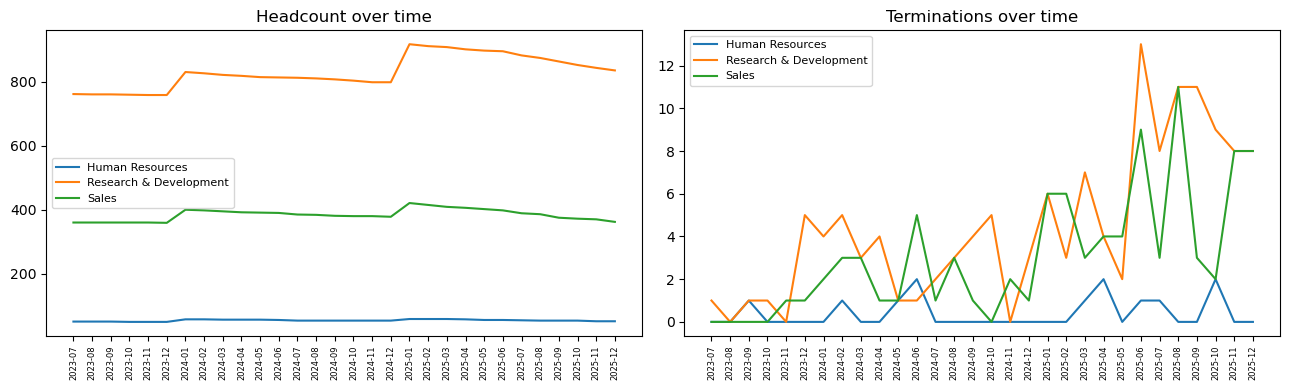

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for dept, sub in panel.groupby("department"):
    axes[0].plot(sub["month"].astype(str), sub["headcount"], label=dept)
    axes[1].plot(sub["month"].astype(str), sub["terminations"], label=dept)
axes[0].set_title("Headcount over time"); axes[0].legend(fontsize=8)
axes[1].set_title("Terminations over time"); axes[1].legend(fontsize=8)
for ax in axes:
    ax.tick_params(axis="x", rotation=90, labelsize=6)
plt.tight_layout()
plt.savefig("../outputs/headcount_terminations_by_dept.png", dpi=120, bbox_inches="tight")
plt.show()

## Sanity check: total terminations in the panel should match the source data's real attrition count

In [5]:
real_leavers = (roster["Attrition"] == "Yes").sum()
panel_terminations = panel["terminations"].sum()
print(f"Real leavers in source data: {real_leavers}")
print(f"Terminations placed in the panel: {panel_terminations}")
assert real_leavers == panel_terminations, "every real leaver should appear exactly once in the panel"
print("OK — matches exactly.")

Real leavers in source data: 237
Terminations placed in the panel: 237
OK — matches exactly.


In [6]:
panel.to_parquet("../data/monthly_panel.parquet", index=False)
print("saved.")

saved.


Next: `02_agent_demo.ipynb` — the conversational query engine over this panel.